In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
forecast = pd.read_csv("../data/processed/prophet_forecast.csv")


In [3]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2011-01-29,-0.032012,-0.706324,0.859486,-0.032012,-0.032012,0.093674,0.093674,0.093674,0.135393,0.135393,0.135393,-0.041719,-0.041719,-0.041719,0.0,0.0,0.0,0.061662
1,2011-01-30,-0.031905,-0.865469,0.756855,-0.031905,-0.031905,-0.022323,-0.022323,-0.022323,0.018212,0.018212,0.018212,-0.040535,-0.040535,-0.040535,0.0,0.0,0.0,-0.054229
2,2011-01-31,-0.031798,-0.880797,0.704518,-0.031798,-0.031798,-0.065411,-0.065411,-0.065411,-0.026876,-0.026876,-0.026876,-0.038535,-0.038535,-0.038535,0.0,0.0,0.0,-0.097209
3,2011-02-01,-0.031691,-0.763584,0.798609,-0.031691,-0.031691,0.002840,0.002840,0.002840,0.038570,0.038570,0.038570,-0.035730,-0.035730,-0.035730,0.0,0.0,0.0,-0.028851
4,2011-02-02,-0.031585,-0.918505,0.642349,-0.031585,-0.031585,-0.103883,-0.103883,-0.103883,-0.071733,-0.071733,-0.071733,-0.032150,-0.032150,-0.032150,0.0,0.0,0.0,-0.135467


In [4]:
actual = pd.read_csv("../data/processed/forecast_dataset.csv")

In [5]:
actual["ds"] = pd.to_datetime(actual["ds"])
forecast["ds"] = pd.to_datetime(forecast["ds"])

In [6]:
evaluation = actual.merge(
    forecast[["ds", "yhat"]],
    on="ds",
    how="inner"
)

In [7]:
evaluation.head()

,ds,y,yhat
0,2011-01-29,0,0.061662
1,2011-01-30,0,-0.054229
2,2011-01-31,0,-0.097209
3,2011-02-01,0,-0.028851
4,2011-02-02,0,-0.135467


In [8]:
mae = mean_absolute_error(
    evaluation["y"],
    evaluation["yhat"]
)

print("MAE:", mae)

MAE: 0.38866908905510295


In [9]:
rmse = np.sqrt(
    mean_squared_error(
        evaluation["y"],
        evaluation["yhat"]
    )
)

print("RMSE:", rmse)

RMSE: 0.6074033308315153


In [10]:
mape = (
    np.mean(
        np.abs(
            (evaluation["y"] - evaluation["yhat"])
            / (evaluation["y"] + 1e-8)
        )
    )
    * 100
)

print("MAPE:", mape)

MAPE: 2085418300.0979807


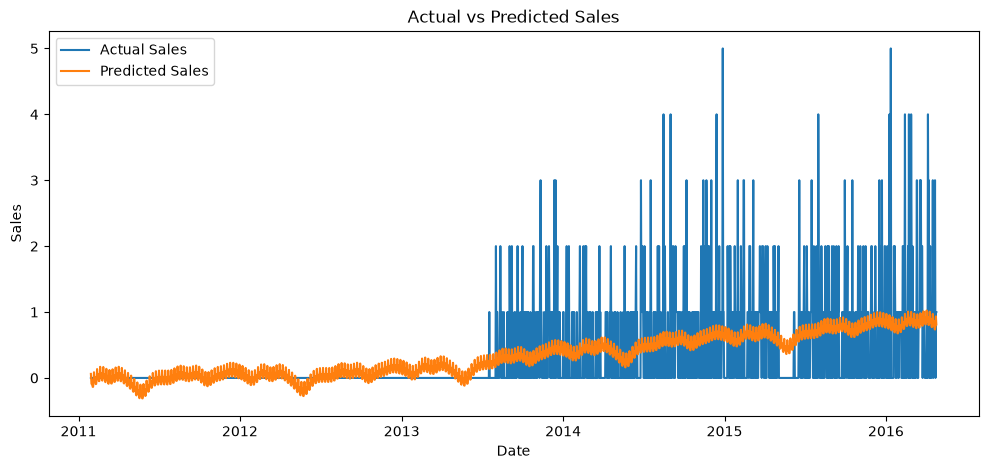

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    evaluation["ds"],
    evaluation["y"],
    label="Actual Sales"
)

plt.plot(
    evaluation["ds"],
    evaluation["yhat"],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

## Model Evaluation

- MAE measures the average prediction error.
- RMSE gives higher weight to larger errors.
- MAPE shows the average percentage error.

Lower values indicate better forecasting performance.


In [12]:
evaluation.to_csv(
    "../data/processed/model_evaluation.csv",
    index=False
)